# YOLO + Qwen3-VL — 스마트공장 인명사고 위험 분석

[AI Hub 스마트 제조 시설 안전 감시 데이터](https://aihub.or.kr/aihubdata/data/view.do?dataSetSn=71679) 샘플(`smart_factory_human_accident.zip`)을 이용해  
**YOLO 객체 탐지 → 탐지 결과 시각화 → Qwen3-VL 장면 설명 → 구조화된 사고 위험 분석(JSON)** 파이프라인을 실행하는 예제입니다.

| 단계 | 내용 |
|------|------|
| 1 | `smart_factory_human_accident.zip` 압축 해제 & YOLO 데이터셋 변환 |
| 2 | YOLO26s 학습(또는 기존 가중치 로드) → human / facility 탐지 |
| 3 | 탐지 bbox 시각화 |
| 4 | Qwen3-VL-4B로 CCTV 장면 설명 |
| 5 | Qwen3-VL + YOLO 공간 관계 → **사고 위험 분석 JSON** 출력 |


---

## QLoRA 파인튜닝 개요 (§10)

이 노트북 후반(§10)에서는 **Qwen3-VL-4B-Instruct**를 **4bit QLoRA**로 스마트공장 도메인에 맞게 미세조정합니다.

### QLoRA란?

| 개념 | 설명 |
|------|------|
| **LoRA** | 거대 LLM 전체를 학습하지 않고, attention 등 일부 레이어에 **저랭크 어댑터**만 추가해 학습 |
| **QLoRA** | 베이스 모델을 **4bit 양자화(NF4)** 로 GPU에 올린 뒤 LoRA만 학습 → 12GB VRAM에서 VLM SFT 가능 |
| **SFT** | Supervised Fine-Tuning. (이미지, 질문) → (정답) 쌍으로 지도학습 |

### 본 노트북의 파인튜닝 전략

1. **Teacher Answer 자동 생성**: AI Hub 라벨 JSON의 bbox·메타(`event=jam`)로 위험도·JSON 정답을 규칙 기반 생성
2. **2종 태스크**: ① 사고 위험 JSON 출력  ② CCTV 장면 한국어 설명 (train 80장 × 2 ≈ 160샘플)
3. **Vision encoder 동결**: `freeze_vision_modules()` — LoRA는 LLM `q_proj`, `v_proj`만 학습
4. **VRAM 절약**: `max_pixels=256×28×28`, batch=1, gradient_accumulation=4, 4bit + gradient checkpointing

### 실행 경로 (추천)

| 목적 | 실행 범위 | 소요 (RTX 3060 12GB) |
|------|-----------|----------------------|
| 추론 파이프라인만 | §0 → §1~§8 | YOLO 학습 시 +10~20분, Qwen3 추론 +수분 |
| QLoRA 학습 포함 | §0 → §10-4 | 학습 약 20~25분 추가 |
| 학습 생략·추론만 | 커널 재시작 → §0 → §10-1 → §10-5 | 어댑터 이미 있을 때 |

<br>


> **관련 노트북**: `07_qwen3_vl_qlora_mini_train.ipynb` (QLoRA 체험) · `08_qwen3_vl_qlora_fine_tuning.ipynb` (KoLLaVA 본격 SFT)

> 선행 참고: `06_qwen3_vl_example.ipynb` · `[참고]13_YOLO26_SmartFactory_Monitor.ipynb`


## 0. 환경 설정

```bash
pip install -r requirements.txt
pip install ultralytics opencv-python-headless
```

| 패키지 | 용도 |
|--------|------|
| `ultralytics` | YOLO26 탐지·학습 |
| `transformers>=4.57.0` | Qwen3-VL |
| `opencv-python-headless` | bbox 시각화 |

<br>

> **VRAM 안내 (RTX 3060 12GB)**: YOLO 학습/추론 후 Qwen3-VL 로드 전 `torch.cuda.empty_cache()`로 GPU 메모리를 비웁니다.
> Qwen3-VL은 `max_pixels` 제한으로 vision 토큰을 줄입니다.

<br>

### QLoRA(§10) 추가 패키지

| 패키지 | 용도 |
|--------|------|
| `trl>=0.9.0` | `SFTTrainer` — VLM 지도학습 |
| `peft>=0.10.0` | LoRA 어댑터 부착·저장 |
| `bitsandbytes>=0.43.0` | 4bit NF4 양자화 (Windows + CUDA) |
| `datasets>=2.18.0` | Hugging Face Dataset |

> Windows에서 QLoRA **학습**은 CUDA GPU 필수. CPU만으로는 §10-4 실행 불가.


In [ ]:
# [패키지 설치] Colab/신규 환경에서 최초 1회만 실행
# ultralytics: YOLO26 | transformers>=4.57: Qwen3-VL | trl/peft/bitsandbytes: §10 QLoRA
# Colab/신규 환경용 — 최초 1회
# %pip install -q ultralytics opencv-python-headless "transformers>=4.57.0" accelerate


In [1]:
# [전역 설정] YOLO·Qwen3-VL·QLoRA 파이프라인 공통 경로·하이퍼파라미터
# ROOT: zip 파일 위치 자동 탐색 | DO_TRAIN: YOLO 재학습 여부
# QWEN_*: §5~§8 추론용 | §10 QLoRA는 별도 TRAIN_* 변수 사용
import json
import math
import re
import shutil
import zipfile
from datetime import datetime, timezone
from io import BytesIO
from pathlib import Path

import cv2
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import torch
import yaml
from IPython.display import Image as IPyImage, display
from PIL import Image
from transformers import AutoProcessor, Qwen3VLForConditionalGeneration
from ultralytics import YOLO, __version__ as ultralytics_version

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# ── 경로 ──
ROOT = Path("/content") if IN_COLAB else Path.cwd()
if not (ROOT / "smart_factory_human_accident.zip").exists():
    for parent in [ROOT, *ROOT.parents]:
        if (parent / "smart_factory_human_accident.zip").exists():
            ROOT = parent
            break

ZIP_PATH = ROOT / "smart_factory_human_accident.zip"
DATA_ROOT = ROOT / "smart_factory"
YOLO_DIR = ROOT / "smart_factory_yolo"
YAML_PATH = YOLO_DIR / "smart_factory.yaml"
OUTPUT_DIR = ROOT / "outputs" / "accident_analysis"
PREDICT_DIR = OUTPUT_DIR / "yolo_predict"

RAW_DIR_NAME = "01.원천데이터"
LABEL_DIR_NAME = "02.라벨링데이터"

# ── YOLO 설정 ──
CLASS_NAMES = ["human", "facility"]
HUMAN_CLASS_ID, FACILITY_CLASS_ID = 0, 1
VAL_VIDEO_STEMS = {"human-accident_jam_rgb_1069_cctv4"}
MODEL_NAME = "yolo26s.pt"
CONF_THRESH = 0.10
EXPERIMENT = "yolo26_smart_factory_v2"
DO_TRAIN = False          # True: 학습 실행 (약 10~20분), False: 기존 best.pt 탐색
TRAIN_EPOCHS = 50         # DO_TRAIN=True일 때 epoch (참고 노트북 13은 150)

# ── Qwen3-VL 설정 ──
QWEN_MODEL_ID = "Qwen/Qwen3-VL-4B-Instruct"
MIN_PIXELS = 256 * 28 * 28
MAX_PIXELS = 768 * 28 * 28

DEVICE = 0 if torch.cuda.is_available() else "cpu"
if torch.cuda.is_available() and torch.cuda.is_bf16_supported():
    QWEN_DTYPE = torch.bfloat16
else:
    QWEN_DTYPE = torch.float16 if torch.cuda.is_available() else torch.float32

# matplotlib 한글
for font in ("Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans KR"):
    if font in {f.name for f in fm.fontManager.ttflist}:
        plt.rcParams["font.family"] = font
        break
plt.rcParams["axes.unicode_minus"] = False

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PREDICT_DIR.mkdir(parents=True, exist_ok=True)

print(f"환경        : {'Colab' if IN_COLAB else '로컬'}")
print(f"Ultralytics : {ultralytics_version}")
print(f"ROOT        : {ROOT.resolve()}")
print(f"Device      : {DEVICE}")
print(f"Qwen dtype  : {QWEN_DTYPE}")


c:\Users\storm\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\cuda\__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


환경        : 로컬
Ultralytics : 8.4.65
ROOT        : C:\MyCursorLab\07_Vision_Language_Model
Device      : 0
Qwen dtype  : torch.bfloat16


## 1. 데이터 준비 — 압축 해제 & YOLO 변환

`smart_factory_human_accident.zip`을 풀고 COCO 형식 라벨을 YOLO bbox 형식(`human` / `facility` 2클래스)으로 변환합니다.


In [2]:
# [데이터 준비] smart_factory_human_accident.zip → YOLO 형식 변환
# extract_zip: CP949 한글 경로 디코딩 | prepare_yolo_dataset: human(0)/facility(1) 2클래스
def data_is_ready(root: Path) -> bool:
# 압축 해제 완료 여부: png·json 존재 확인
    if not root.exists():
        return False
    pngs = [p for p in root.rglob("*.png") if "eda" not in p.parts]
    jsons = [p for p in root.rglob("*.json") if "eda" not in p.parts]
    return len(pngs) > 0 and len(jsons) > 0


def has_correct_korean_paths(root: Path) -> bool:
    if not root.exists():
        return False
    dirs = [p.name for p in root.iterdir() if p.is_dir() and p.name != "eda"]
    return RAW_DIR_NAME in dirs and LABEL_DIR_NAME in dirs


def extract_zip(zip_path: Path, extract_to: Path, force: bool = False) -> None:
# Windows CP949/EUC-KR 한글 폴더명 디코딩 지원
    if not zip_path.exists():
        raise FileNotFoundError(
            f"압축 파일이 없습니다: {zip_path}\n"
            "AI Hub에서 smart_factory_human_accident.zip을 다운로드해 프로젝트 루트에 두세요."
        )
    extract_to.mkdir(parents=True, exist_ok=True)
    if not force and data_is_ready(extract_to) and has_correct_korean_paths(extract_to):
        print("이미 압축 해제됨 — 스킵")
        return
    for child in extract_to.iterdir():
        if child.is_dir() and child.name != "eda":
            shutil.rmtree(child)
    with zipfile.ZipFile(zip_path) as zf:
        for info in zf.infolist():
            name = info.filename if (info.flag_bits & 0x800) else info.filename.encode("cp437").decode("cp949")
            target = extract_to / name
            if info.is_dir() or name.endswith("/"):
                target.mkdir(parents=True, exist_ok=True)
            else:
                target.parent.mkdir(parents=True, exist_ok=True)
                with zf.open(info) as src, open(target, "wb") as dst:
                    dst.write(src.read())
    print(f"압축 해제 완료: {extract_to.resolve()}")


def find_raw_and_label_roots(root: Path) -> tuple[Path, Path]:
    raw, label = root / RAW_DIR_NAME, root / LABEL_DIR_NAME
    if raw.exists() and label.exists():
        return raw, label
    candidates = [p for p in root.iterdir() if p.is_dir() and p.name != "eda"]
    return (
        max(candidates, key=lambda p: len(list(p.rglob("*.png")))),
        max(candidates, key=lambda p: len(list(p.rglob("*.json")))),
    )


def seg_to_bbox_xywh(segmentation: list[float]) -> tuple[float, float, float, float]:
    xs, ys = segmentation[0::2], segmentation[1::2]
    return min(xs), min(ys), max(xs) - min(xs), max(ys) - min(ys)


def coco_to_yolo(x, y, w, h, img_w, img_h):
    return (x + w / 2) / img_w, (y + h / 2) / img_h, w / img_w, h / img_h


def prepare_yolo_dataset(root: Path, output_dir: Path) -> dict:
# COCO형 라벨 → YOLO txt (human=seg, facility=bbox)
    raw_root, label_root = find_raw_and_label_roots(root)
    for split in ("train", "val"):
        (output_dir / "images" / split).mkdir(parents=True, exist_ok=True)
        (output_dir / "labels" / split).mkdir(parents=True, exist_ok=True)

    stats = {"train": 0, "val": 0, "skipped": 0}
    for json_path in sorted(label_root.rglob("*.json")):
        data = json.loads(json_path.read_text(encoding="utf-8-sig"))
        if "annotations" not in data:
            continue
        meta = data["meta_information"]
        rel = json_path.parent.relative_to(label_root)
        split = "val" if rel.parts[-1] in VAL_VIDEO_STEMS else "train"
# VAL_VIDEO_STEMS: val split 고정 (cctv4 영상)
        src_img = raw_root / rel / meta["file_name"]
        if not src_img.exists():
            stats["skipped"] += 1
            continue

        stem = Path(meta["file_name"]).stem
        dst_img = output_dir / "images" / split / f"{stem}.png"
        dst_lbl = output_dir / "labels" / split / f"{stem}.txt"
        shutil.copy2(src_img, dst_img)

        lines = []
        for ann in data["annotations"]:
            obj_id = ann.get("id", "")
            if obj_id.startswith("h") and ann.get("segmentation"):
                x, y, w, h = seg_to_bbox_xywh(ann["segmentation"])
                xc, yc, nw, nh = coco_to_yolo(x, y, w, h, int(meta["width"]), int(meta["height"]))
                lines.append(f"{HUMAN_CLASS_ID} {xc:.6f} {yc:.6f} {nw:.6f} {nh:.6f}")
            elif obj_id.startswith("m") and ann.get("bbox"):
                x, y, w, h = ann["bbox"]
                xc, yc, nw, nh = coco_to_yolo(x, y, w, h, int(meta["width"]), int(meta["height"]))
                lines.append(f"{FACILITY_CLASS_ID} {xc:.6f} {yc:.6f} {nw:.6f} {nh:.6f}")
        dst_lbl.write_text("\n".join(lines) + ("\n" if lines else ""), encoding="utf-8")
        stats[split] += 1

    YAML_PATH.write_text(
        f"path: {output_dir.resolve()}\n"
        f"train: images/train\n"
        f"val: images/val\n"
        f"nc: {len(CLASS_NAMES)}\n"
        f"names:\n" + "".join(f"  - {n}\n" for n in CLASS_NAMES),
        encoding="utf-8",
    )
    stats["yaml"] = str(YAML_PATH)
    return stats


need_extract = not data_is_ready(DATA_ROOT) or not has_correct_korean_paths(DATA_ROOT)
extract_zip(ZIP_PATH, DATA_ROOT, force=need_extract)

for cache in YOLO_DIR.rglob("*.cache"):
    cache.unlink(missing_ok=True)

stats = prepare_yolo_dataset(DATA_ROOT, YOLO_DIR)
cfg = yaml.safe_load(YAML_PATH.read_text(encoding="utf-8"))
print("YOLO 데이터셋:", stats)
print("클래스:", cfg["names"])
print(f"train: {len(list((YOLO_DIR / 'images/train').glob('*.png')))}장, val: {len(list((YOLO_DIR / 'images/val').glob('*.png')))}장")


압축 해제 완료: C:\MyCursorLab\07_Vision_Language_Model\smart_factory
YOLO 데이터셋: {'train': 80, 'val': 20, 'skipped': 0, 'yaml': 'c:\\MyCursorLab\\07_Vision_Language_Model\\smart_factory_yolo\\smart_factory.yaml'}
클래스: ['human', 'facility']
train: 80장, val: 20장


## 2. YOLO26 모델 — 학습 또는 가중치 로드

`DO_TRAIN=False`(기본)이면 `runs/detect/` 아래 기존 `best.pt`를 찾습니다. 없으면 `DO_TRAIN=True`로 학습하세요.


In [ ]:
# [YOLO26] 기존 best.pt 탐색 또는 DO_TRAIN=True 시 학습
# CONF_THRESH=0.10: YOLO26은 confidence가 낮게 출력되는 경향 (참고 노트북 13)
def find_best_weights() -> Path | None:
# 로컬·06_Object_Detection·smart_factory 경로에서 best.pt 탐색
    candidates = [
        ROOT / "runs" / "detect" / EXPERIMENT / "weights" / "best.pt",
        ROOT.parent / "06_Object_Detection" / "runs" / "detect" / EXPERIMENT / "weights" / "best.pt",
    ]
    for p in candidates:
        if p.exists():
            return p
    for p in sorted(ROOT.rglob("best.pt")):
        if EXPERIMENT in str(p) or "smart_factory" in str(p):
            return p
    return None


BEST_WEIGHTS = find_best_weights()

if DO_TRAIN or BEST_WEIGHTS is None:
# 가중치 없으면 YOLO26s 학습 자동 시작
    print(f"YOLO26 학습 시작 (epochs={TRAIN_EPOCHS})...")
    model = YOLO(MODEL_NAME)
    results = model.train(
        data=str(YAML_PATH),
        epochs=TRAIN_EPOCHS,
        imgsz=640,
        batch=8,
        device=DEVICE,
        name=EXPERIMENT,
        exist_ok=True,
        patience=30,
        lr0=0.001,
        mosaic=0.3,
        mixup=0.0,
        copy_paste=0.0,
        close_mosaic=10,
        freeze=10,
        workers=0,
        plots=True,
    )
    BEST_WEIGHTS = Path(results.save_dir) / "weights" / "best.pt"
else:
    print(f"기존 가중치 사용: {BEST_WEIGHTS.resolve()}")

yolo_model = YOLO(str(BEST_WEIGHTS))
print(f"YOLO 모델 준비 완료 | conf={CONF_THRESH}")

# RTX 3060 : 약 7분 소요

YOLO26 학습 시작 (epochs=50)...
New https://pypi.org/project/ultralytics/8.4.67 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.65  Python-3.11.9 torch-2.11.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\MyCursorLab\07_Vision_Language_Model\smart_factory_yolo\smart_factory.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0,

## 3. YOLO 객체 탐지 & 결과 시각화

성형·밀링·사출 설비 샘플 3장에 대해 human/facility bbox를 탐지하고 오버레이 이미지를 표시합니다.


Results saved to C:\MyCursorLab\07_Vision_Language_Model\outputs\accident_analysis\yolo_predict\human-accident_jam_rgb_0957_cctv1_05

[molding-machine | human-accident_jam_rgb_0957_cctv1_05.png]


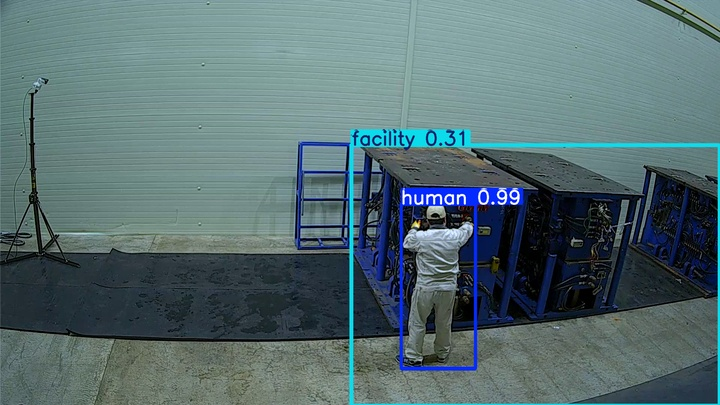

  설비(원본): molding-machine | human=2, facility=2
    human: conf=0.989
    human: conf=0.517
    facility: conf=0.312
    facility: conf=0.237
Results saved to C:\MyCursorLab\07_Vision_Language_Model\outputs\accident_analysis\yolo_predict\human-accident_jam_rgb_1048_cctv3_05

[milling-machine | human-accident_jam_rgb_1048_cctv3_05.png]


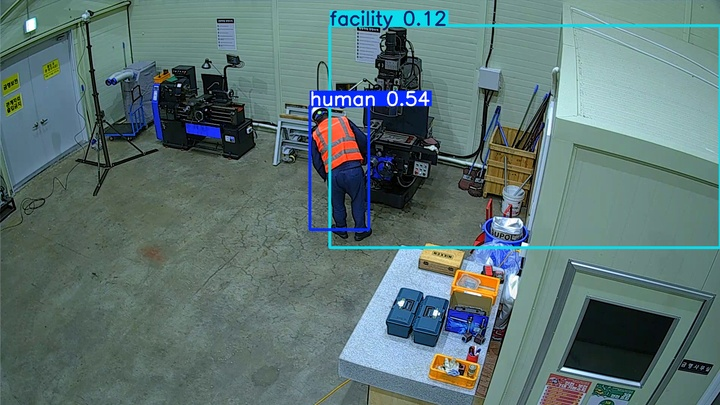

  설비(원본): milling-machine | human=1, facility=1
    human: conf=0.541
    facility: conf=0.118
Results saved to C:\MyCursorLab\07_Vision_Language_Model\outputs\accident_analysis\yolo_predict\human-accident_jam_rgb_2031_cctv3_05

[injection-machine | human-accident_jam_rgb_2031_cctv3_05.png]


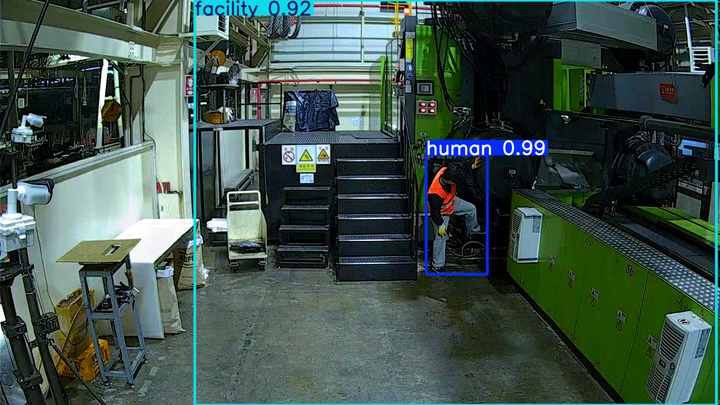

  설비(원본): injection-machine | human=1, facility=1
    human: conf=0.990
    facility: conf=0.916


In [4]:
# [YOLO 추론·시각화] 3종 설비 샘플 이미지에 human/facility bbox 탐지
# detection_results: 이후 Qwen3-VL·JSON 분석(§6~§8)에서 재사용
FACILITY_SAMPLE_STEMS = [
    ("molding-machine", "human-accident_jam_rgb_0957_cctv1_05"),
    ("milling-machine", "human-accident_jam_rgb_1048_cctv3_05"),
    ("injection-machine", "human-accident_jam_rgb_2031_cctv3_05"),
]


def resolve_yolo_image(stem: str) -> Path:
    for split in ("train", "val"):
        path = YOLO_DIR / "images" / split / f"{stem}.png"
        if path.exists():
            return path
    raise FileNotFoundError(f"이미지 없음: {stem}.png")


def show_yolo_result(result, title: str = "", width: int = 720) -> Image.Image:
    plotted = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)
    pil_img = Image.fromarray(plotted)
    if pil_img.width > width:
        ratio = width / pil_img.width
        pil_img = pil_img.resize((width, int(pil_img.height * ratio)), Image.LANCZOS)
    buf = BytesIO()
    pil_img.save(buf, format="JPEG", quality=95)
    if title:
        print(f"\n[{title}]")
    display(IPyImage(data=buf.getvalue(), width=width))
    return pil_img


def yolo_result_to_dict(result) -> dict:
# Ultralytics Results → JSON 직렬화 가능 dict
    objects = []
    for i, box in enumerate(result.boxes):
        cls_name = result.names[int(box.cls)]
        xyxy = [round(float(v), 1) for v in box.xyxy[0].tolist()]
        x1, y1, x2, y2 = xyxy
        objects.append({
            "id": f"obj_{i}",
            "class": cls_name,
            "confidence": round(float(box.conf), 4),
            "bbox_xyxy": xyxy,
            "center": [round((x1 + x2) / 2, 1), round((y1 + y2) / 2, 1)],
        })
    h, w = result.orig_shape
    return {
        "scene_id": Path(result.path).stem,
        "image": {"path": str(result.path), "width": w, "height": h},
        "detector": {"model": EXPERIMENT, "conf_threshold": CONF_THRESH},
        "objects": objects,
        "counts": {
            "human": sum(1 for o in objects if o["class"] == "human"),
            "facility": sum(1 for o in objects if o["class"] == "facility"),
            "total": len(objects),
        },
    }


# ── 탐지 실행 ──
detection_results: list[tuple[str, Path, object, Image.Image, dict]] = []

for facility_name, stem in FACILITY_SAMPLE_STEMS:
# 성형·밀링·사출 설비 대표 프레임 각 1장
    img_path = resolve_yolo_image(stem)
    preds = yolo_model.predict(
        source=str(img_path),
        conf=CONF_THRESH,
        save=True,
        project=str(PREDICT_DIR),
        name=stem,
        exist_ok=True,
        device=DEVICE,
        verbose=False,
    )
    result = preds[0]
    if len(result.boxes) == 0:
        result = yolo_model.predict(str(img_path), conf=0.05, device=DEVICE, verbose=False)[0]

    scene_dict = yolo_result_to_dict(result)
    annotated = show_yolo_result(result, title=f"{facility_name} | {img_path.name}")

    humans = scene_dict["counts"]["human"]
    facilities = scene_dict["counts"]["facility"]
    print(f"  설비(원본): {facility_name} | human={humans}, facility={facilities}")
    for obj in scene_dict["objects"]:
        print(f"    {obj['class']}: conf={obj['confidence']:.3f}")

    detection_results.append((facility_name, img_path, result, annotated, scene_dict))


## 4. YOLO 공간 관계 분석 (기하학적 위험도)

human ↔ facility bbox 간 IoU·중심 거리로 **끼임(overlap) / 근접(near) / 안전(far)** 관계를 추론합니다.


In [5]:
# [공간 관계] YOLO bbox 기반 human↔facility IoU·거리 → 끼임/근접/안전 분류
# infer_spatial_relationships: §7 JSON의 yolo_spatial_analysis 입력
def bbox_iou(a: list[float], b: list[float]) -> float:
# 두 bbox 겹침 정도 (0~1). 높을수록 끼임 위험
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    inter_x1, inter_y1 = max(ax1, bx1), max(ay1, by1)
    inter_x2, inter_y2 = min(ax2, bx2), min(ay2, by2)
    inter = max(0.0, inter_x2 - inter_x1) * max(0.0, inter_y2 - inter_y1)
    if inter == 0:
        return 0.0
    area_a = (ax2 - ax1) * (ay2 - ay1)
    area_b = (bx2 - bx1) * (by2 - by1)
    return inter / (area_a + area_b - inter)


def infer_spatial_relationships(scene: dict, near_px: float = 120.0, hazard_iou: float = 0.05) -> list[dict]:
# human×facility 모든 쌍에 대해 spatial predicate 추론
    humans = [o for o in scene["objects"] if o["class"] == "human"]
    facilities = [o for o in scene["objects"] if o["class"] == "facility"]
    relations = []
    for human in humans:
        for facility in facilities:
            iou = bbox_iou(human["bbox_xyxy"], facility["bbox_xyxy"])
            dist = math.hypot(human["center"][0] - facility["center"][0], human["center"][1] - facility["center"][1])
            if iou >= hazard_iou:
                predicate, risk, semantic = "overlaps_with", "high", "pinch_hazard_overlap"
            elif dist <= near_px:
                predicate, risk, semantic = "near", "medium", "worker_proximity_to_machine"
            else:
                predicate, risk, semantic = "far_from", "low", "safe_distance"
            relations.append({
                "subject": human["id"],
                "predicate": predicate,
                "object": facility["id"],
                "metrics": {"iou": round(iou, 4), "center_distance_px": round(dist, 1)},
                "semantic": semantic,
                "risk_level": risk,
            })
    return relations


def yolo_risk_summary(relations: list[dict]) -> dict:
# 관계 목록에서 scene 전체 alert 수준 집계
    risks = [r["risk_level"] for r in relations]
    if "high" in risks:
        alert = "pinch_hazard_detected"
    elif "medium" in risks:
        alert = "worker_near_machine"
    else:
        alert = "normal"
    return {
        "alert": alert,
        "relation_count": len(relations),
        "max_risk": max(risks, default="none"),
    }


# 첫 번째 샘플에 공간 관계 적용 (데모)
_, _, _, _, demo_scene = detection_results[0]
demo_relations = infer_spatial_relationships(demo_scene)
demo_yolo_summary = yolo_risk_summary(demo_relations)

print("=== YOLO 공간 관계 (샘플 1) ===")
for rel in demo_relations:
    print(
        f"  {rel['subject']} --[{rel['predicate']}]--> {rel['object']}"
        f" | {rel['semantic']} (risk={rel['risk_level']})"
    )
print("\nYOLO 위험 요약:", json.dumps(demo_yolo_summary, ensure_ascii=False, indent=2))


=== YOLO 공간 관계 (샘플 1) ===
  obj_0 --[overlaps_with]--> obj_2 | pinch_hazard_overlap (risk=high)
  obj_0 --[overlaps_with]--> obj_3 | pinch_hazard_overlap (risk=high)
  obj_1 --[overlaps_with]--> obj_2 | pinch_hazard_overlap (risk=high)
  obj_1 --[overlaps_with]--> obj_3 | pinch_hazard_overlap (risk=high)

YOLO 위험 요약: {
  "alert": "pinch_hazard_detected",
  "relation_count": 4,
  "max_risk": "high"
}


## 5. Qwen3-VL 모델 로드

YOLO 추론이 끝나면 GPU 메모리를 비운 뒤 Qwen3-VL-4B-Instruct를 로드합니다.


In [6]:
# [Qwen3-VL 로드] §5~§8 추론용 — YOLO 해제 후 VRAM 확보 필수
# device_map=auto: accelerate 설치 시 멀티 GPU/단일 GPU 자동 배치
# YOLO 모델 해제 → VRAM 확보
del yolo_model
if torch.cuda.is_available():
    torch.cuda.empty_cache()

try:
    import accelerate  # noqa: F401
    has_accelerate = True
except ImportError:
    has_accelerate = False

load_kwargs = {"dtype": QWEN_DTYPE, "low_cpu_mem_usage": True}
if torch.cuda.is_available() and has_accelerate:
    load_kwargs["device_map"] = "auto"

qwen_model = Qwen3VLForConditionalGeneration.from_pretrained(QWEN_MODEL_ID, **load_kwargs)
qwen_processor = AutoProcessor.from_pretrained(QWEN_MODEL_ID)
qwen_processor.image_processor.size = {"shortest_edge": MIN_PIXELS, "longest_edge": MAX_PIXELS}

if not (torch.cuda.is_available() and has_accelerate):
    qwen_model = qwen_model.to(DEVICE if isinstance(DEVICE, str) else "cuda")
qwen_model.eval()

print(f"Qwen3-VL 로드 완료: {QWEN_MODEL_ID}")
print(f"모델 디바이스: {next(qwen_model.parameters()).device}")


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

Qwen3-VL 로드 완료: Qwen/Qwen3-VL-4B-Instruct
모델 디바이스: cuda:0


## 6. Qwen3-VL — CCTV 장면 설명

YOLO 탐지 bbox 정보를 텍스트 힌트로 함께 전달해, VLM이 **작업자·설비·행동**을 자연어로 설명합니다.


In [7]:
# [Qwen3-VL 추론 헬퍼] ask_qwen3: 단일 이미지+질문 → 텍스트 응답
# build_yolo_hint: YOLO 탐지·공간관계를 VLM 프롬프트 힌트 문자열로 변환
def decode_qwen(inputs, output_ids) -> str:
# 입력 프롬프트 토큰 제외, 생성된 assistant 토큰만 디코딩
    trimmed = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs["input_ids"], output_ids)]
    return qwen_processor.batch_decode(trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0].strip()


def move_inputs_to_model(inputs: dict) -> dict:
    model_device = next(qwen_model.parameters()).device
    moved = {}
    for key, value in inputs.items():
        if not hasattr(value, "to"):
            moved[key] = value
        elif key == "pixel_values":
            moved[key] = value.to(model_device, dtype=QWEN_DTYPE)
        else:
            moved[key] = value.to(model_device)
    return moved


def ask_qwen3(image: Image.Image, question: str, max_new_tokens: int = 512) -> str:
# Qwen3-VL 단일 턴 VQA/분석 추론
    conversation = [{
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": question},
        ],
    }]
    inputs = qwen_processor.apply_chat_template(
        conversation,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
    )
    inputs = move_inputs_to_model(inputs)
    with torch.no_grad():
        output_ids = qwen_model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    return decode_qwen(inputs, output_ids)


def build_yolo_hint(scene: dict, relations: list[dict]) -> str:
# YOLO 결과를 VLM 프롬프트에 주입할 텍스트 힌트
    lines = [
        f"- human {scene['counts']['human']}명, facility(설비) {scene['counts']['facility']}대 탐지됨",
    ]
    for rel in relations:
        lines.append(f"- {rel['subject']} {rel['predicate']} {rel['object']} (위험={rel['risk_level']}, {rel['semantic']})")
    return "\n".join(lines)


# 첫 번째 샘플: 원본 + YOLO 힌트 기반 장면 설명
demo_facility, demo_path, _, demo_annotated, demo_scene = detection_results[0]
demo_relations = infer_spatial_relationships(demo_scene)
yolo_hint = build_yolo_hint(demo_scene, demo_relations)

describe_prompt = (
    "당신은 스마트공장 CCTV 안전 모니터링 전문가입니다.\n"
    "아래 이미지는 제조 현장 CCTV 프레임입니다. YOLO 객체 탐지 결과를 참고하세요:\n\n"
    f"{yolo_hint}\n\n"
    "다음을 한국어로 3~5문장으로 설명하세요:\n"
    "1) 현장 환경 (설비 종류, 작업자 수)\n"
    "2) 작업자의 위치·자세·행동\n"
    "3) 설비와의 거리/접촉 여부\n"
    "4) 눈에 띄는 안전 위험 요소"
)

scene_description = ask_qwen3(demo_annotated, describe_prompt)
print("=== Qwen3-VL 장면 설명 ===")
print(scene_description)


=== Qwen3-VL 장면 설명 ===
1) 현장은 스마트공장 내 제조 설비 구역으로, 파란색 대형 전기/냉각 설비 2대가 배치되어 있으며, 작업자 2명이 동시에 설비 근처에서 작업 중입니다.  
2) 작업자들은 모두 흰색 작업복을 입고, 설비의 상부 구조에 손을 뻗어 조작하거나 점검하는 자세로 서 있으며, 설비와 직접 접촉하고 있습니다.  
3) 작업자들은 설비의 개방된 구조부분에 가까운 위치에 서 있어, 설비의 움직임이나 기계 부품과 접촉할 위험이 높습니다.  
4) 가장 눈에 띄는 안전 위험 요소는 작업자들이 설비와 겹치는 영역(overlaps)에 위치해 있어, 손가락이나 몸이 갈라진 상태로 부딪힐 수 있는 ‘pinch hazard’ 위험이 매우 높습니다.


## 7. Qwen3-VL — 구조화된 사고 위험 분석 (JSON)

VLM에게 **JSON만** 출력하도록 요청하고, YOLO 공간 분석 결과와 병합해 최종 리포트를 생성합니다.


In [ ]:
# [사고 분석 JSON] VLM에게 스키마 지시 → JSON 파싱 → YOLO 결과와 merged_risk 병합
# all_reports: 3샘플 분석 결과 리스트, OUTPUT_DIR에 개별 JSON 저장
ACCIDENT_JSON_SCHEMA = {
# VLM 출력 JSON 스키마 (프롬프트에 포함)
    "scene_id": "string",
    "timestamp_utc": "ISO8601",
    "facility_type": "molding-machine | milling-machine | injection-machine | unknown",
    "scene_description": "string (한국어)",
    "workers": [{"count": "int", "behavior": "string", "ppe_status": "string"}],
    "hazards": [{"type": "string", "severity": "low|medium|high|critical", "description": "string", "evidence": "string"}],
    "risk_assessment": {
        "overall_risk": "low|medium|high|critical",
        "accident_type": "pinch|fall|collision|none|unknown",
        "immediate_action_required": "bool",
        "recommended_actions": ["string"],
    },
    "yolo_spatial_analysis": {
        "alert": "string",
        "max_risk": "string",
        "relationships": "list",
    },
}


def extract_json_from_text(text: str) -> dict:
# ```json``` 래핑·앞뒤 잡텍스트 제거 후 json.loads
    text = text.strip()
    if text.startswith("```"):
        text = re.sub(r"^```(?:json)?\s*", "", text)
        text = re.sub(r"\s*```$", "", text)
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        match = re.search(r"\{.*\}", text, re.DOTALL)
        if match:
            return json.loads(match.group())
        raise


def analyze_accident_json(
# YOLO+프롬프트 → VLM JSON → yolo_detection·vlm_analysis·merged_risk 통합
    image: Image.Image,
    facility_type: str,
    scene_id: str,
    yolo_scene: dict,
    yolo_relations: list[dict],
    yolo_summary: dict,
    scene_desc: str,
) -> dict:
    yolo_hint = build_yolo_hint(yolo_scene, yolo_relations)
    prompt = (
        "스마트공장 CCTV 프레임의 **인명사고·끼임 위험**을 분석하세요.\n"
        f"설비 유형(원본 데이터): {facility_type}\n"
        f"scene_id: {scene_id}\n\n"
        "[YOLO 탐지 + 공간 관계]\n"
        f"{yolo_hint}\n"
        f"YOLO alert: {yolo_summary['alert']}, max_risk: {yolo_summary['max_risk']}\n\n"
        "[장면 설명 (참고)]\n"
        f"{scene_desc}\n\n"
        "**반드시 아래 JSON 스키마만** 출력하세요. 다른 텍스트·마크다운 없이 순수 JSON:\n"
        f"{json.dumps(ACCIDENT_JSON_SCHEMA, ensure_ascii=False, indent=2)}\n\n"
        "필드 가이드:\n"
        "- hazards: pinch(끼임), proximity(근접), ppe_missing(보호구 미착용) 등\n"
        "- accident_type: pinch(끼임), fall(추락), collision(충돌), none, unknown\n"
        "- recommended_actions: 한국어로 구체적 조치 (예: 비상정지, 작업자 대피)"
    )

    raw = ask_qwen3(image, prompt, max_new_tokens=768)
    vlm_json = extract_json_from_text(raw)

    final = {
        "scene_id": scene_id,
        "timestamp_utc": datetime.now(timezone.utc).isoformat(),
        "facility_type": facility_type,
        "pipeline": {
            "detector": "YOLO26s (human/facility)",
            "vlm": QWEN_MODEL_ID,
            "version": "11_yolo_qwen3_smart_factory",
        },
        "yolo_detection": yolo_scene,
        "yolo_spatial_analysis": {
            "alert": yolo_summary["alert"],
            "max_risk": yolo_summary["max_risk"],
            "relationships": yolo_relations,
        },
        "vlm_analysis": vlm_json,
        "merged_risk": {
            "overall_risk": vlm_json.get("risk_assessment", {}).get("overall_risk", yolo_summary["max_risk"]),
            "sources": {
                "yolo_alert": yolo_summary["alert"],
                "vlm_accident_type": vlm_json.get("risk_assessment", {}).get("accident_type", "unknown"),
            },
        },
    }
    return final


# ── 3개 샘플 모두 분석 ──
all_reports: list[dict] = []

for facility_name, img_path, _, annotated, scene_dict in detection_results:
# §3에서 탐지한 3샘플 각각 사고 분석 JSON 생성
    relations = infer_spatial_relationships(scene_dict)
    summary = yolo_risk_summary(relations)

    desc_prompt = (
        f"스마트공장 CCTV입니다. YOLO: human={scene_dict['counts']['human']}, "
        f"facility={scene_dict['counts']['facility']}.\n"
        f"설비: {facility_name}. 작업자·설비·위험 상황을 한국어 2~3문장으로 설명하세요."
    )
    desc = ask_qwen3(annotated, desc_prompt, max_new_tokens=256)

    report = analyze_accident_json(
        image=annotated,
        facility_type=facility_name,
        scene_id=scene_dict["scene_id"],
        yolo_scene=scene_dict,
        yolo_relations=relations,
        yolo_summary=summary,
        scene_desc=desc,
    )
    all_reports.append(report)

    out_path = OUTPUT_DIR / f"{report['scene_id']}_accident_analysis.json"
    out_path.write_text(json.dumps(report, ensure_ascii=False, indent=2), encoding="utf-8")
    print(f"\n{'='*60}")
    print(f"[{facility_name}] {report['scene_id']}")
    print(f"  YOLO alert : {summary['alert']} (max_risk={summary['max_risk']})")
    print(f"  VLM risk   : {report['merged_risk']['overall_risk']}")
    print(f"  저장       : {out_path.resolve()}")

# RTX 3060 : 약 17분 소요


[molding-machine] human-accident_jam_rgb_0957_cctv1_05
  YOLO alert : pinch_hazard_detected (max_risk=high)
  VLM risk   : high
  저장       : C:\MyCursorLab\07_Vision_Language_Model\outputs\accident_analysis\human-accident_jam_rgb_0957_cctv1_05_accident_analysis.json

[milling-machine] human-accident_jam_rgb_1048_cctv3_05
  YOLO alert : pinch_hazard_detected (max_risk=high)
  VLM risk   : high
  저장       : C:\MyCursorLab\07_Vision_Language_Model\outputs\accident_analysis\human-accident_jam_rgb_1048_cctv3_05_accident_analysis.json

[injection-machine] human-accident_jam_rgb_2031_cctv3_05
  YOLO alert : worker_near_machine (max_risk=medium)
  VLM risk   : medium
  저장       : C:\MyCursorLab\07_Vision_Language_Model\outputs\accident_analysis\human-accident_jam_rgb_2031_cctv3_05_accident_analysis.json


## 8. 최종 JSON 출력 & 요약 비교


In [9]:
# [결과 출력] 샘플 1 전체 JSON + 3샘플 위험도 비교 테이블 + all_accident_reports.json 일괄 저장
# 첫 번째 샘플 전체 JSON 출력
print("=== 최종 사고 위험 분석 JSON (샘플 1) ===")
print(json.dumps(all_reports[0], ensure_ascii=False, indent=2))

# 3샘플 요약 테이블
print("\n=== 3샘플 위험도 비교 ===")
for r in all_reports:
    yolo = r["yolo_spatial_analysis"]
    vlm = r["vlm_analysis"].get("risk_assessment", {})
    print(
        f"  {r['scene_id']:45s} | "
        f"YOLO={yolo['alert']:25s} | "
        f"VLM={vlm.get('overall_risk', '?'):8s} | "
        f"사고유형={vlm.get('accident_type', '?')}"
    )

# 일괄 저장
batch_path = OUTPUT_DIR / "all_accident_reports.json"
batch_path.write_text(json.dumps(all_reports, ensure_ascii=False, indent=2), encoding="utf-8")
print(f"\n일괄 저장: {batch_path.resolve()}")


=== 최종 사고 위험 분석 JSON (샘플 1) ===
{
  "scene_id": "human-accident_jam_rgb_0957_cctv1_05",
  "timestamp_utc": "2026-06-14T14:03:36.808190+00:00",
  "facility_type": "molding-machine",
  "pipeline": {
    "detector": "YOLO26s (human/facility)",
    "vlm": "Qwen/Qwen3-VL-4B-Instruct",
    "version": "11_yolo_qwen3_smart_factory"
  },
  "yolo_detection": {
    "scene_id": "human-accident_jam_rgb_0957_cctv1_05",
    "image": {
      "path": "c:\\MyCursorLab\\07_Vision_Language_Model\\smart_factory_yolo\\images\\train\\human-accident_jam_rgb_0957_cctv1_05.png",
      "width": 1920,
      "height": 1080
    },
    "detector": {
      "model": "yolo26_smart_factory_v2",
      "conf_threshold": 0.1
    },
    "objects": [
      {
        "id": "obj_0",
        "class": "human",
        "confidence": 0.9891,
        "bbox_xyxy": [
          1069.9,
          545.1,
          1268.7,
          981.3
        ],
        "center": [
          1169.3,
          763.2
        ]
      },
      {
        

## 9. 추론 파이프라인 정리

| 단계 | 기술 | 출력 |
|------|------|------|
| 객체 탐지 | YOLO26s (human/facility) | bbox + confidence |
| 시각화 | Ultralytics `result.plot()` | bbox 오버레이 이미지 |
| 장면 이해 | Qwen3-VL-4B | 한국어 장면 설명 |
| 위험 분석 | YOLO IoU/거리 + Qwen3-VL | `*_accident_analysis.json` |

**파이프라인 흐름:**

```
CCTV 프레임 → YOLO 탐지 → bbox 시각화 → Qwen3-VL 설명 → JSON 사고 분석
                     ↘ IoU/거리 공간 관계 ───────────────↗
```

> **다음 섹션** 에서 동일 도메인 데이터로 Qwen3-VL **QLoRA 파인튜닝**을 진행한다.

### §10으로 이어지는 이유

§1~§8은 **베이스 Qwen3-VL**로 사고 분석 JSON을 생성합니다. §10에서는 동일한 출력 형식을 **teacher data**로 만들어 QLoRA SFT를 수행하고, §10-5에서 베이스 vs LoRA 품질을 비교합니다.


## 10. QLoRA 파인튜닝 — 스마트공장 사고 분석 특화

앞선 파이프라인(§1~§8)에서 생성한 **구조화 JSON 분석 형식**을 Qwen3-VL이 학습하도록  
**4bit QLoRA** SFT를 수행합니다. 라벨 JSON의 bbox·메타정보로 teacher answer를 만들어 소규모 도메인 적응을 체험합니다.

| 항목 | 설정 |
|------|------|
| 베이스 | `Qwen/Qwen3-VL-4B-Instruct` |
| 방법 | 4bit QLoRA (`bitsandbytes` + `peft`) |
| 데이터 | smart_factory train 80장 × 2태스크 ≈ 160샘플 |
| VRAM | RTX 3060 12GB (`max_pixels` 제한 필수) |
| 출력 | `./qwen3-vl-4b-qlora-smart-factory/` |

> **선행 조건**: §1 데이터 준비 완료. §5에서 로드한 `qwen_model`은 아래 셀에서 GPU 메모리 확보를 위해 해제합니다.  
> `DO_QLORA = False`로 두면 학습을 건너뛰고 저장된 어댑터만 로드합니다.


### QLoRA 파이프라인 상세

```
라벨 JSON + PNG
    → build_sft_samples()     : image_path + user_prompt + teacher answer
    → qlora_collate_fn()      : PIL 로드 → chat template → tensor
    → SFTTrainer + peft_config: 4bit 베이스 + LoRA 학습
    → ./qwen3-vl-4b-qlora-smart-factory/  : adapter + processor 저장
    → PeftModel.from_pretrained + disable_adapter() : 베이스/LoRA 비교 추론
```

### 주요 플래그

| 변수 | 기본값 | 의미 |
|------|--------|------|
| `DO_QLORA` | `True` | `False`이고 어댑터 있으면 §10-4 학습 스킵 |
| `NUM_EPOCHS` | `3` | epoch ↑ → 시간·과적합 주의 |
| `TRAIN_MAX_PIXELS` | `256×28×28` | vision 토큰 상한 (OOM 방지) |
| `INFER_DTYPE` (§10-5) | `float16` | 4bit 추론 시 visual Conv3d CUDA 호환 |

### VRAM 주의

- §10-4 학습 직후 §10-5 실행 시 **GPU 메모리 부족** 가능 → `release_infer_models()` 또는 **커널 재시작** 후 §10-5만 실행
- 4bit QLoRA는 **CPU offload 불가** → `device_map={"": 0}` 단일 GPU 로드


In [ ]:
# [QLoRA 패키지] §10 전용 — trl(SFTTrainer), peft(LoRA), bitsandbytes(4bit), datasets
# QLoRA 추가 패키지 (Colab/신규 환경 — 최초 1회)
# %pip install -q "trl>=0.9.0" "peft>=0.10.0" "bitsandbytes>=0.43.0" "datasets>=2.18.0"

In [15]:
# [QLoRA 하이퍼파라미터] DO_QLORA: 학습 실행 여부 | QLORA_OUTPUT_DIR: 어댑터 저장 경로
# §5 qwen_model 해제: QLoRA 학습 전 VRAM 확보 (약 7~8GB 필요)
import gc
import inspect
import time

from datasets import Dataset
from peft import LoraConfig, PeftModel, prepare_model_for_kbit_training
from transformers import AutoProcessor, BitsAndBytesConfig, Qwen3VLForConditionalGeneration
from trl import SFTConfig, SFTTrainer

# ── QLoRA 하이퍼파라미터 (RTX 3060 12GB) ──
DO_QLORA = True
QLORA_OUTPUT_DIR = ROOT / "qwen3-vl-4b-qlora-smart-factory"
QLORA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

NUM_EPOCHS = 3
BATCH_SIZE = 1
GRAD_ACCUM = 4
LEARNING_RATE = 2e-4
LORA_R = 8
LORA_ALPHA = 16
TRAIN_MAX_PIXELS = 256 * 28 * 28   # 학습용 vision 토큰 상한 (OOM 방지)
TRAIN_MIN_PIXELS = 256 * 28 * 28
MAX_ANSWER_CHARS = 900

SYSTEM_PROMPT = (
    "당신은 스마트공장 CCTV 안전 모니터링 AI입니다. "
    "작업자·설비·끼임 사고 위험을 분석하고 한국어 JSON으로 답합니다."
)

JSON_USER_PROMPT = (
    "이 CCTV 프레임의 인명사고·끼임 위험을 분석하세요. "
    "scene_description, workers, hazards, risk_assessment(overall_risk, accident_type, "
    "immediate_action_required, recommended_actions) 필드를 포함한 **순수 JSON만** 출력하세요."
)

DESC_USER_PROMPT = (
    "이 스마트공장 CCTV 이미지를 보고, 설비 종류·작업자 행동·안전 위험 요소를 "
    "한국어 2~3문장으로 설명하세요."
)

# §5 Qwen3 추론 모델 해제 → QLoRA 학습용 VRAM 확보
for _name in ("qwen_model", "qwen_processor"):
    if _name in globals():
        del globals()[_name]
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f"GPU 메모리 확보: {torch.cuda.memory_allocated()/1024**3:.2f} GB 사용 중")
print(f"DO_QLORA={DO_QLORA} | 출력: {QLORA_OUTPUT_DIR.resolve()}")


GPU 메모리 확보: 3.65 GB 사용 중
DO_QLORA=True | 출력: C:\MyCursorLab\07_Vision_Language_Model\qwen3-vl-4b-qlora-smart-factory


### 10-1. 학습 데이터셋 구축

라벨 JSON의 bbox로 human/facility 공간 관계를 계산하고, 메타정보(`event=jam`)를 반영한 **teacher JSON**을 assistant 정답으로 사용합니다.

**Teacher Answer 생성 규칙**
- `event=jam` → `accident_type: pinch` (끼임)
- human↔facility bbox IoU ≥ 0.05 → `overall_risk: high`
- 중심 거리 ≤ 120px → `medium`, 그 외 → `low`

> PIL Image는 `Dataset.from_list()` 저장 시 dict로 변환되므로 **`image_path`만 저장**하고 `collate_fn`에서 로드합니다.


In [16]:
# [SFT 데이터셋] 라벨 JSON bbox → teacher JSON/설명 생성 → image_path 기반 샘플 리스트
# build_train_messages: collate_fn에서 PIL 로드 후 Qwen3 chat 형식 구성
# train 80장 × 2태스크(JSON+설명) ≈ 160 SFT 샘플
FACILITY_BY_VIDEO = {
# 영상 stem → 설비 유형 매핑 (AI Hub 메타 보조)
    "human-accident_jam_rgb_0957_cctv1": "molding-machine",
    "human-accident_jam_rgb_1048_cctv3": "milling-machine",
    "human-accident_jam_rgb_2031_cctv3": "injection-machine",
    "human-accident_jam_rgb_1892_cctv3": "injection-machine",
}


def video_stem_from_frame(stem: str) -> str:
    if stem.endswith("_01") or "_" not in stem:
        return stem.rsplit("_", 1)[0] if stem[-3:].isdigit() else stem
    return stem.rsplit("_", 1)[0]


def parse_label_objects(data: dict) -> tuple[list[dict], list[dict]]:
    meta = data["meta_information"]
    w, h = int(meta["width"]), int(meta["height"])
    humans, facilities = [], []
    for ann in data.get("annotations", []):
        obj_id = str(ann.get("id", ""))
        if obj_id.startswith("h"):
            if ann.get("segmentation"):
                xs, ys = ann["segmentation"][0::2], ann["segmentation"][1::2]
                x1, y1, x2, y2 = min(xs), min(ys), max(xs), max(ys)
            else:
                x, y, bw, bh = ann["bbox"]
                x1, y1, x2, y2 = x, y, x + bw, y + bh
            humans.append({"id": obj_id, "bbox_xyxy": [x1, y1, x2, y2]})
        elif obj_id.startswith("m") and ann.get("bbox"):
            x, y, bw, bh = ann["bbox"]
            facilities.append({"id": obj_id, "bbox_xyxy": [x, y, x + bw, y + bh]})
    return humans, facilities


def label_relations(humans: list[dict], facilities: list[dict]) -> list[dict]:
    relations = []
    for human in humans:
        hx = (human["bbox_xyxy"][0] + human["bbox_xyxy"][2]) / 2
        hy = (human["bbox_xyxy"][1] + human["bbox_xyxy"][3]) / 2
        for fac in facilities:
            iou = bbox_iou(human["bbox_xyxy"], fac["bbox_xyxy"])
            fx = (fac["bbox_xyxy"][0] + fac["bbox_xyxy"][2]) / 2
            fy = (fac["bbox_xyxy"][1] + fac["bbox_xyxy"][3]) / 2
            dist = math.hypot(hx - fx, hy - fy)
            if iou >= 0.05:
                risk, semantic = "high", "pinch_hazard_overlap"
            elif dist <= 120:
                risk, semantic = "medium", "worker_proximity_to_machine"
            else:
                risk, semantic = "low", "safe_distance"
            relations.append({"risk_level": risk, "semantic": semantic, "iou": iou, "dist": dist})
    return relations


def build_teacher_json(scene_id: str, meta: dict, facility_type: str, relations: list[dict]) -> str:
# SFT assistant 정답: 규칙 기반 사고 분석 JSON 문자열
    n_workers = meta.get("_human_count", 1)
    n_facility = meta.get("_facility_count", 1)
    event = meta.get("event", "jam")
    risks = [r["risk_level"] for r in relations]
    max_risk = max(risks, default="low")
    overall = {"high": "high", "medium": "medium"}.get(max_risk, "low")
    accident_type = "pinch" if event == "jam" else "unknown"
    immediate = overall == "high"

    if overall == "high":
        actions = ["즉시 설비 비상정지", "작업자 안전 구역 대피 안내", "현장 관리자 호출"]
        hazard_desc = "작업자와 설비 bbox가 겹쳐 끼임(jam) 위험이 높음"
    elif overall == "medium":
        actions = ["설비 가동 상태 확인", "작업자 안전 거리 확보 안내"]
        hazard_desc = "작업자가 설비 근접 구역에서 작업 중"
    else:
        actions = ["정기 안전 순찰 유지"]
        hazard_desc = "현재 뚜렷한 끼임 위험은 낮음"

    payload = {
        "scene_id": scene_id,
        "facility_type": facility_type,
        "scene_description": (
            f"실내 제조 현장 CCTV({meta.get('camera_id', 'cctv')}). "
            f"{facility_type} 설비 주변에 작업자 {n_workers}명, 설비 {n_facility}대가 보입니다. "
            f"{hazard_desc}."
        ),
        "workers": [{
            "count": n_workers,
            "behavior": "설비 인근 작업",
            "ppe_status": "확인 필요",
        }],
        "hazards": [{
            "type": "pinch" if event == "jam" else "proximity",
            "severity": overall,
            "description": hazard_desc,
            "evidence": f"라벨 bbox 기반 spatial analysis (max_risk={max_risk})",
        }] if relations else [],
        "risk_assessment": {
            "overall_risk": overall,
            "accident_type": accident_type,
            "immediate_action_required": immediate,
            "recommended_actions": actions,
        },
    }
    return json.dumps(payload, ensure_ascii=False)


def build_teacher_description(meta: dict, facility_type: str, relations: list[dict]) -> str:
# SFT assistant 정답: 장면 설명 한국어 2~3문장
    n_workers = meta.get("_human_count", 1)
    risks = [r["risk_level"] for r in relations]
    max_risk = max(risks, default="low")
    risk_ko = {"high": "높음", "medium": "중간", "low": "낮음"}.get(max_risk, "낮음")
    return (
        f"{facility_type} 설비가 보이는 실내 제조 현장입니다. "
        f"작업자 {n_workers}명이 설비 근처에서 작업 중이며, "
        f"끼임 사고 위험은 {risk_ko} 수준으로 판단됩니다."
    )


def build_sft_samples(split: str = "train") -> list[dict]:
# train PNG 순회 → image_path·prompt·answer 레코드 생성
    _, label_root = find_raw_and_label_roots(DATA_ROOT)
    img_dir = YOLO_DIR / "images" / split
    samples = []

    for img_path in sorted(img_dir.glob("*.png")):
        matches = list(label_root.rglob(f"{img_path.stem}.json"))
        if not matches:
            continue
        data = json.loads(matches[0].read_text(encoding="utf-8-sig"))
        meta = data["meta_information"]
        humans, facilities = parse_label_objects(data)
        meta["_human_count"] = len(humans)
        meta["_facility_count"] = len(facilities)
        relations = label_relations(humans, facilities)
        video = video_stem_from_frame(img_path.stem)
        facility_type = FACILITY_BY_VIDEO.get(video, "manufacturing-equipment")


        json_answer = build_teacher_json(img_path.stem, meta, facility_type, relations)
        desc_answer = build_teacher_description(meta, facility_type, relations)

        for user_prompt, answer in (
            (JSON_USER_PROMPT, json_answer),
            (DESC_USER_PROMPT, desc_answer),
        ):
            # PIL Image는 Dataset 저장 시 dict로 변환됨 → 경로만 저장, collate_fn에서 로드
# ↑ HuggingFace Dataset PIL 직렬화 이슈 회피 (필수 패턴)
            samples.append({
                "image_path": str(img_path.resolve()),
                "user_prompt": user_prompt,
                "answer": answer[:MAX_ANSWER_CHARS],
                "scene_id": img_path.stem,
                "task": user_prompt[:20],
            })

    return samples


def build_train_messages(image: Image.Image, user_prompt: str, answer: str) -> list[dict]:
    return [
        {"role": "system", "content": [{"type": "text", "text": SYSTEM_PROMPT}]},
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": user_prompt},
            ],
        },
        {"role": "assistant", "content": [{"type": "text", "text": answer}]},
    ]


sft_records = build_sft_samples("train")
train_dataset = Dataset.from_list(sft_records)
print(f"SFT train 샘플: {len(train_dataset)} (train PNG × 2 tasks)")
print("예시 scene:", train_dataset[0]["scene_id"], "| task:", train_dataset[0]["task"])
print("assistant 미리보기:", train_dataset[0]["answer"][:200], "...")

# 약 2.5분 소요

SFT train 샘플: 160 (train PNG × 2 tasks)
예시 scene: human-accident_jam_rgb_0957_cctv1_01 | task: 이 CCTV 프레임의 인명사고·끼임 
assistant 미리보기: {"scene_id": "human-accident_jam_rgb_0957_cctv1_01", "facility_type": "manufacturing-equipment", "scene_description": "실내 제조 현장 CCTV(cctv1). manufacturing-equipment 설비 주변에 작업자 1명, 설비 1대가 보입니다. 작업자와 설비 ...


### 10-2. 4bit QLoRA 모델 로드

- `prepare_model_for_kbit_training`: gradient checkpointing 등 k-bit 학습 준비
- `patch_input_embeddings`: Qwen3-VL + checkpointing 시 NotImplementedError 방지
- `freeze_vision_modules`: visual encoder 가중치 동결 (LoRA는 LLM만)
- **§10-2만 실행해도 학습은 시작되지 않음** — 실제 `trainer.train()`은 §10-4


In [17]:
# [QLoRA 모델 준비] 4bit 베이스 로드 + k-bit 학습 설정 + LoRA config
# DO_QLORA=False & adapter 존재 시: 모델 로드 스킵 (§10-5 추론만 할 때)
def clear_gpu():
# gc + empty_cache + synchronize — VRAM 해제
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()


def freeze_vision_modules(model):
# visual/vision 파라미터 requires_grad=False
    for name, param in model.named_parameters():
        if "visual" in name or "vision" in name:
            param.requires_grad = False


def patch_input_embeddings(model):
# Qwen3-VL gradient checkpointing 호환 패치
    inner = model.get_model() if hasattr(model, "get_model") else model.model
    if not hasattr(inner, "get_input_embeddings") or inner.get_input_embeddings() is None:
        def get_input_embeddings(self):
            return self.language_model.get_input_embeddings()
        inner.get_input_embeddings = get_input_embeddings.__get__(inner, type(inner))


def configure_qwen3_processor(processor, min_pixels: int, max_pixels: int):
# vision 토큰 pixel 상·하한 — OOM 방지 핵심
    processor.image_processor.min_pixels = min_pixels
    processor.image_processor.max_pixels = max_pixels
    if hasattr(processor.image_processor, "size"):
        processor.image_processor.size = {"shortest_edge": min_pixels, "longest_edge": max_pixels}
    return processor


if not DO_QLORA and (QLORA_OUTPUT_DIR / "adapter_config.json").exists():
    print("DO_QLORA=False — 기존 어댑터 사용:", QLORA_OUTPUT_DIR)
else:
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16,
        bnb_4bit_use_double_quant=True,
    )

    qlora_model = Qwen3VLForConditionalGeneration.from_pretrained(
        QWEN_MODEL_ID,
        quantization_config=bnb_config,
        device_map="auto",
        low_cpu_mem_usage=True,
    )
    qlora_processor = AutoProcessor.from_pretrained(QWEN_MODEL_ID)
    qlora_processor = configure_qwen3_processor(qlora_processor, TRAIN_MIN_PIXELS, TRAIN_MAX_PIXELS)

    qlora_model = prepare_model_for_kbit_training(qlora_model, use_gradient_checkpointing=True)
    qlora_model.config.use_cache = False
    patch_input_embeddings(qlora_model)
    freeze_vision_modules(qlora_model)

    peft_config = LoraConfig(
# LoRA: r=8, target q_proj/v_proj — LLM attention만 미세조정
        r=LORA_R,
        lora_alpha=LORA_ALPHA,
        lora_dropout=0.05,
        bias="none",
        target_modules=["q_proj", "v_proj"],
        task_type="CAUSAL_LM",
    )

    allocated = torch.cuda.memory_allocated() / 1024**3
    print(f"QLoRA 모델 로드 | GPU: {allocated:.2f} GB")


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

QLoRA 모델 로드 | GPU: 7.10 GB


### 10-3. collate_fn & SFTTrainer

- VLM은 `max_length` truncation 사용 금지 (vision 토큰 잘림 오류)
- `mask_vision_tokens`: vision 특수 토큰을 labels `-100`으로 마스킹 (loss 제외)
- `assistant_only_loss=False`: TRL VLM은 user 구간 loss 마스킹 미지원 (전체 시퀀스 loss)


In [18]:
# [SFTTrainer 설정] qlora_collate_fn: 배치마다 image_path→PIL→processor tensor
# max_length=None 필수: VLM truncation 시 vision 토큰 불일치 OOM/오류
def mask_vision_tokens(labels, tokenizer):
# <|vision_start|> 등 특수 토큰 loss 제외 (labels=-100)
    for token in ("<|vision_start|>", "<|vision_end|>", "<|vision_pad|>", "<|image_pad|>", "<|video_pad|>"):
        token_id = tokenizer.convert_tokens_to_ids(token)
        if token_id is not None and token_id != tokenizer.unk_token_id:
            labels[labels == token_id] = -100
    return labels


def qlora_collate_fn(examples):
# DataLoader 배치: image_path→PIL→chat template→input_ids·pixel_values·labels
    messages_list = []
    images = []
    for ex in examples:
        img = Image.open(ex["image_path"]).convert("RGB")
        messages_list.append(build_train_messages(img, ex["user_prompt"], ex["answer"]))
        images.append([img])
    texts = [qlora_processor.apply_chat_template(m, tokenize=False) for m in messages_list]
    batch = qlora_processor(text=texts, images=images, return_tensors="pt", padding=True)
    labels = batch["input_ids"].clone()
    labels[labels == qlora_processor.tokenizer.pad_token_id] = -100
    labels = mask_vision_tokens(labels, qlora_processor.tokenizer)
    batch["labels"] = labels
    return batch


if DO_QLORA or not (QLORA_OUTPUT_DIR / "adapter_config.json").exists():
    sft_kwargs = dict(
        output_dir=str(QLORA_OUTPUT_DIR),
        num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        gradient_accumulation_steps=GRAD_ACCUM,
        gradient_checkpointing=True,
        gradient_checkpointing_kwargs={"use_reentrant": False},
        optim="paged_adamw_8bit",
        learning_rate=LEARNING_RATE,
        lr_scheduler_type="cosine",
        warmup_ratio=0.05,
        logging_steps=4,
        save_strategy="epoch",
        eval_strategy="no",
        fp16=False,
        bf16=False,
        max_grad_norm=0.3,
        report_to="none",
        remove_unused_columns=False,
        dataset_kwargs={"skip_prepare_dataset": True},
        dataloader_num_workers=0,
        max_length=None,
        assistant_only_loss=False,
    )
    training_args = SFTConfig(**sft_kwargs)
# fp16/bf16=False: QLoRA+PEFT AMP dtype 충돌 방지
    print("SFTConfig 준비 완료")


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


SFTConfig 준비 완료


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_21008\3988189755.py:50: FutureWarning: The default `loss_type` will change from `'nll'` to `'chunked_nll'` in TRL 1.7. For standard models this is transparent (same math, lower memory) and no action is needed — you'll get the new default automatically on upgrade. If you use a custom model, check ahead of time that `loss_type='chunked_nll'` runs and yields the same loss as `'nll'`; if it doesn't, pin `loss_type='nll'` to keep the current behavior and please open an issue at https://github.com/huggingface/trl/issues so we can address the edge case.
  training_args = SFTConfig(**sft_kwargs)


### 10-4. QLoRA 학습 실행 & 어댑터 저장

학습 완료 후 `adapter_config.json`, LoRA 가중치, processor가 `QLORA_OUTPUT_DIR`에 저장됩니다.  
재학습 없이 §10-5만 실행하려면 `DO_QLORA=False`로 설정하세요.


In [19]:
# [QLoRA 학습 실행] SFTTrainer.train() → adapter·processor 저장 → GPU 해제
# DO_QLORA=False & adapter 있으면: "학습 스킵" 메시지만 출력
if DO_QLORA or not (QLORA_OUTPUT_DIR / "adapter_config.json").exists():
    trainer_kwargs = dict(
        model=qlora_model,
        args=training_args,
        train_dataset=train_dataset,
        data_collator=qlora_collate_fn,
        peft_config=peft_config,
    )
    if "processing_class" in inspect.signature(SFTTrainer.__init__).parameters:
        trainer_kwargs["processing_class"] = qlora_processor
    else:
        trainer_kwargs["tokenizer"] = qlora_processor.tokenizer

    trainer = SFTTrainer(**trainer_kwargs)
# peft_config 전달 시 LoRA 어댑터 자동 부착

    print("=" * 50)
    print("QLoRA 학습 시작")
    t0 = time.time()
    train_result = trainer.train()
# 실제 QLoRA 역전파·가중치 업데이트 (§10-2는 여기까지 도달하지 않음)
    print("=" * 50)
    print(f"학습 완료 | { (time.time()-t0)/60:.1f}분 | loss={train_result.training_loss:.4f}")

    trainer.save_model(str(QLORA_OUTPUT_DIR))
# LoRA adapter만 저장 (~수십 MB), 베이스 4B는 저장 안 함
    qlora_processor.save_pretrained(str(QLORA_OUTPUT_DIR))
    print(f"어댑터 저장: {QLORA_OUTPUT_DIR.resolve()}")

    del trainer, qlora_model
    clear_gpu()
else:
    print("학습 스킵 (DO_QLORA=False, 어댑터 존재)")

# RTX 3060 : 약 21분 소요

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 151645, 'bos_token_id': None, 'pad_token_id': 151643}.


QLoRA 학습 시작


Step,Training Loss
4,2.826626
8,2.746839
12,2.245784
16,1.897398
20,1.570008
24,1.217269
28,1.014280
32,0.710867
36,0.627710
40,0.333230


학습 완료 | 21.1분 | loss=0.5414
어댑터 저장: C:\MyCursorLab\07_Vision_Language_Model\qwen3-vl-4b-qlora-smart-factory


### 10-5. LoRA vs 베이스 — 사고 분석 JSON 비교

val 샘플 1장에 대해 **베이스 Qwen3-VL**과 **QLoRA 어댑터**의 JSON 출력을 비교합니다.

- **베이스**: `lora_model.disable_adapter()` — 4bit 원본 Qwen3-VL
- **LoRA**: adapter ON — §10에서 학습한 스마트공장 특화 가중치
- **`INFER_DTYPE=float16`**: bf16 + bitsandbytes visual encoder 조합 시 Conv3d CUDA 오류 방지


In [23]:
# [QLoRA 추론 비교] fp16 고정 + release_infer_models() + disable_adapter() 베이스/LoRA 비교
# infer_device_map={"":0}: 4bit는 CPU offload 불가 → 단일 GPU 전체 로드
# 4bit QLoRA 추론: fp16 고정 (bf16 + bitsandbytes visual Conv3d CUDA 오류 방지)
INFER_DTYPE = torch.float16
# 4bit 추론 fp16 고정 — bf16은 visual Conv3d CUDA 미지원 경로 유발


def move_infer_inputs(inputs: dict, model, dtype: torch.dtype) -> dict:
# pixel_values를 모델 device·INFER_DTYPE으로 이동
    """입력 텐서를 모델 디바이스·dtype에 맞게 이동."""
    device = next(model.parameters()).device
    moved = {}
    for key, value in inputs.items():
        if not hasattr(value, "to"):
            moved[key] = value
        elif key == "pixel_values":
            moved[key] = value.to(device, dtype=dtype)
        else:
            moved[key] = value.to(device)
    return moved


def qlora_generate(model, processor, image: Image.Image, question: str, max_new_tokens: int = 512) -> str:
# PeftModel 또는 base 4bit에 대한 VLM generate
    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": image.convert("RGB")},
            {"type": "text", "text": question},
        ],
    }]
    inputs = processor.apply_chat_template(
        messages, add_generation_prompt=True, tokenize=True, return_dict=True, return_tensors="pt"
    )
    inputs = move_infer_inputs(inputs, model, INFER_DTYPE)
    with torch.inference_mode():
        out_ids = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    trimmed = out_ids[0, inputs["input_ids"].shape[1]:]
    return processor.decode(trimmed, skip_special_tokens=True).strip()


def print_pretty_json_answer(text: str) -> None:
    """VLM 응답에서 JSON을 추출해 indent=2로 출력. 파싱 실패 시 원문 출력."""
    try:
        parsed = extract_json_from_text(text)
        print(json.dumps(parsed, ensure_ascii=False, indent=2))
    except Exception:
        print(text)


# val 이미지 1장 선택
val_imgs = sorted((YOLO_DIR / "images" / "val").glob("*.png"))
compare_img_path = val_imgs[0] if val_imgs else resolve_yolo_image(FACILITY_SAMPLE_STEMS[0][1])
compare_image = Image.open(compare_img_path).convert("RGB")
compare_prompt = JSON_USER_PROMPT


def release_infer_models():
# §10-4 trainer·qlora_model 등 GPU 점유 객체 일괄 del
    """§10-4 학습 모델 등 GPU 점유 객체 해제 (4bit는 CPU offload 불가)."""
    for name in (
        "trainer", "qlora_model", "qlora_processor", "peft_config",
        "base_4bit", "lora_model", "infer_model", "qwen_model", "qwen_processor",
        "yolo_model", "model", "base_model",
    ):
        if name in globals():
            del globals()[name]
    clear_gpu()
    if torch.cuda.is_available():
        torch.cuda.synchronize()
        print(f"GPU 해제 후 VRAM: {torch.cuda.memory_allocated()/1024**3:.2f} GB")


release_infer_models()

bnb_infer = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=INFER_DTYPE,
    bnb_4bit_use_double_quant=True,
)

# 학습 시 저장한 processor 우선 (chat template·pixel 설정 일치)
infer_processor = AutoProcessor.from_pretrained(str(QLORA_OUTPUT_DIR))
infer_processor = configure_qwen3_processor(infer_processor, TRAIN_MIN_PIXELS, TRAIN_MAX_PIXELS)

# 4bit QLoRA는 CPU/disk offload 불가 → 단일 GPU(0)에 전체 로드
infer_device_map = {"": 0} if torch.cuda.is_available() else "auto"
base_4bit = Qwen3VLForConditionalGeneration.from_pretrained(
    QWEN_MODEL_ID,
    quantization_config=bnb_infer,
    device_map=infer_device_map,
    torch_dtype=INFER_DTYPE,
    low_cpu_mem_usage=True,
)
lora_model = PeftModel.from_pretrained(base_4bit, str(QLORA_OUTPUT_DIR))
lora_model.eval()
lora_model.config.use_cache = True

print(f"비교 이미지: {compare_img_path.name}")
print(f"추론 dtype: {INFER_DTYPE} | VRAM: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

print("\n--- 베이스 Qwen3-VL (adapter OFF) ---")
with lora_model.disable_adapter():
# adapter OFF = 베이스 4bit Qwen3-VL과 동일하게 추론
    base_answer = qlora_generate(lora_model, infer_processor, compare_image, compare_prompt)
print_pretty_json_answer(base_answer)

print("\n--- QLoRA 어댑터 (adapter ON) ---")
lora_answer = qlora_generate(lora_model, infer_processor, compare_image, compare_prompt)
print_pretty_json_answer(lora_answer)

for label, text in [("base", base_answer), ("lora", lora_answer)]:
    try:
        parsed = extract_json_from_text(text)
        risk = parsed.get("risk_assessment", {}).get("overall_risk", "?")
        print(f"  [{label}] JSON 파싱 OK | overall_risk={risk}")
    except Exception as e:
        print(f"  [{label}] JSON 파싱 실패: {e}")

del base_4bit, lora_model
clear_gpu()

# RTX 3060 : 약 1분 30초 소요

GPU 해제 후 VRAM: 4.97 GB


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

비교 이미지: human-accident_jam_rgb_1069_cctv4_01.png
추론 dtype: torch.float16 | VRAM: 7.70 GB

--- 베이스 Qwen3-VL (adapter OFF) ---
{
  "scene_description": "작업장 내에서 작업자 1명이 기계 장비(대형 기계)에 접근 중이며, 안전장비(안전모, 반사복)를 착용하고 있지만, 기계 주변에 다른 장비(로드, 테이블, 수건 등)가 배치되어 있어 작업 공간이 협박되고, 기계 작동 중에 부상 위험이 존재함.",
  "workers": [
    {
      "id": 1,
      "role": "작업자",
      "description": "안전장비 착용, 기계 조작 중"
    }
  ],
  "hazards": [
    "기계 작동 중 부상 위험",
    "작업장 공간 협박",
    "기계 주변 장비로 인한 충돌 위험",
    "기계 조작 시 손상 위험"
  ],
  "risk_assessment": {
    "overall_risk": "중간",
    "accident_type": "기계 부상",
    "immediate_action_required": "작업자에게 즉시 안전한 위치로 이동하라고 지시하고, 기계 작동 중에는 접근 금지",
    "recommended_actions": [
      "작업장 내 기계 주변에 충돌 위험을 줄이기 위한 장비 배치 재조정",
      "작업자에게 안전 교육 강화",
      "기계 작동 중에는 반드시 안전장비 외에도 추가적인 감시 필요",
      "작업장 내 안전 점검 및 위험 요소 정리"
    ]
  }
}

--- QLoRA 어댑터 (adapter ON) ---
{
  "scene_id": "human-accident-pinching-risk-cctv3_13",
  "facility_type": "공장",
  "scene_description": "실내 제조 현장 CCTV(cct

## 11. 전체 정리

| 단계 | 기술 | 출력 |
|------|------|------|
| 객체 탐지 | YOLO26s (human/facility) | bbox + confidence |
| 시각화 | Ultralytics `result.plot()` | bbox 오버레이 |
| 장면 이해 | Qwen3-VL-4B | 한국어 장면 설명 |
| 위험 분석 | YOLO + Qwen3-VL | `*_accident_analysis.json` |
| **도메인 적응** | **QLoRA SFT** | `./qwen3-vl-4b-qlora-smart-factory/` |

```
smart_factory_human_accident.zip
  → YOLO 탐지/시각화 → Qwen3-VL JSON 분석
                              ↓
              라벨 기반 SFT 데이터 → QLoRA 파인튜닝 → LoRA 추론 비교
```

**관련:** `07_qwen3_vl_qlora_mini_train.ipynb` · `08_qwen3_vl_qlora_fine_tuning.ipynb` · `06_qwen3_vl_example.ipynb`


---

## QLoRA 파인튜닝 요약

| 항목 | 내용 |
|------|------|
| 베이스 | `Qwen/Qwen3-VL-4B-Instruct` |
| 방법 | 4bit NF4 + LoRA (`r=8`, `q_proj`/`v_proj`) |
| 데이터 | smart_factory train 80장 × 2태스크 |
| 출력 | `./qwen3-vl-4b-qlora-smart-factory/` |
| 한계 | 소규모 teacher data → **데모·파이프라인 체험** 수준 (실 배포 품질 아님) |

## 확장 가이드

1. **데이터 확장**: AI Hub 전체 데이터 + 사람 검수 teacher answer
2. **본격 SFT**: `08_qwen3_vl_qlora_fine_tuning.ipynb` + KoLLaVA 등 대규모 한국어 VLM 데이터
3. **실시간 연동**: YOLO bbox → QLoRA VLM JSON → `immediate_action_required=true` 시 알림 Webhook
4. **영상 배치**: `[참고]13` 노트북처럼 MP4 프레임 단위 파이프라인 적용

